# Imports

In [1]:
!pip install numpy scikit-learn pandas torch matplotlib seaborn mnist mnist-utils
import numpy as np
import sklearn as skl
import pandas as pd
import torch as tr
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
os.system(f'rm -f mnist_reader.py')
!wget https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/utils/mnist_reader.py
import mnist_reader

--2026-06-12 18:46:52--  https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/utils/mnist_reader.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 756 [text/plain]
Saving to: ‘mnist_reader.py’

mnist_reader.py     100%[===================>]     756  --.-KB/s    in 0s      

2026-06-12 18:46:52 (15.0 MB/s) - ‘mnist_reader.py’ saved [756/756]



# Dataset

In [2]:
os.makedirs('data/fashion', exist_ok=True)

base_url = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/'
files = [
    'train-images-idx3-ubyte.gz',
    'train-labels-idx1-ubyte.gz',
    't10k-images-idx3-ubyte.gz',
    't10k-labels-idx1-ubyte.gz',
]

for f in files:
    os.system(f'rm -f data/fashion/{f} && wget -P data/fashion {base_url}{f}')

In [3]:
dataTrainRaw, targetTrainRaw = mnist_reader.load_mnist('data/fashion', kind='train')
dataTest, targetTest = mnist_reader.load_mnist('data/fashion', kind='t10k')

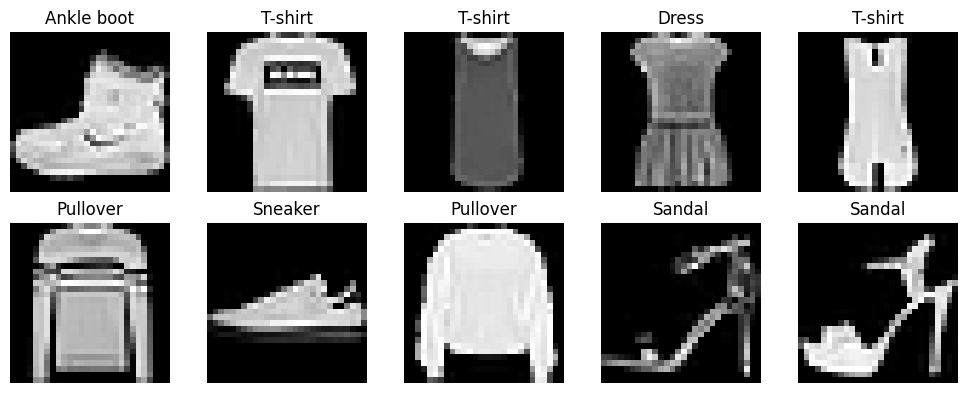

In [4]:
classes = ['T-shirt','Trouser','Pullover','Dress','Coat', 'Sandal','Shirt','Sneaker','Bag','Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(dataTrainRaw[i].reshape(28, 28), cmap='gray')
    ax.set_title(classes[targetTrainRaw[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Data Transformation

In [5]:
dataTrain, dataVal, targetTrain, targetVal = skl.model_selection.train_test_split( dataTrainRaw, targetTrainRaw, test_size=0.25, random_state=42, stratify=targetTrainRaw)

print(f"Conjunto de treino: {dataTrain.shape[0]} amostras")
print(f"Conjunto de validação: {dataVal.shape[0]} amostras")
print(f"Conjunto de teste: {dataTest.shape[0]} amostras")

# Normalização dos dados
scaler = skl.preprocessing.MinMaxScaler()
dataTrainScaled = scaler.fit_transform(dataTrain)
dataValScaled = scaler.transform(dataVal)
dataTestScaled = scaler.transform(dataTest)

print("\nDados normalizados com sucesso!")
print(f"Média dos dados de treino: {dataTrainScaled.mean():.4f}")
print(f"Desvio padrão dos dados de treino: {dataTrainScaled.std():.4f}")

Conjunto de treino: 45000 amostras
Conjunto de validação: 15000 amostras
Conjunto de teste: 10000 amostras

Dados normalizados com sucesso!
Média dos dados de treino: 0.2863
Desvio padrão dos dados de treino: 0.3533


Normalizing the information of each pixel, from range [0...255] to [0...1].

# PyTorch

In [7]:
class MLPPyTorch(tr.nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.2, activation='relu'):
        super().__init__()

        activations = {
            'relu':       tr.nn.ReLU(),
            'leaky_relu': tr.nn.LeakyReLU(negative_slope=0.01),
            'elu':        tr.nn.ELU(alpha=1.0),
            'swish':      tr.nn.SiLU(),
        }
        act = activations[activation]

        layers = [tr.nn.Linear(input_size, hidden_sizes[0]), act]
        for i in range(1, len(hidden_sizes)):
            layers += [tr.nn.Linear(hidden_sizes[i-1], hidden_sizes[i]), act, tr.nn.Dropout(dropout_rate)]
        layers.append(tr.nn.Linear(hidden_sizes[-1], num_classes))

        self.network = tr.nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Configuração do modelo
device = tr.device('cuda' if tr.cuda.is_available() else 'cpu')

model_pytorch = MLPPyTorch(
    input_size=784,  # 28x28 pixels
    hidden_sizes=[256, 128],
    num_classes=10,
    dropout_rate=0.2
).to(device)

print(model_pytorch)
print(f"\nNúmero total de parâmetros: {sum(p.numel() for p in model_pytorch.parameters())}")

MLPPyTorch(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Número total de parâmetros: 235146


In [8]:
dataTrainTensor = tr.FloatTensor(dataTrainScaled).to(device)
targetTrainTensor = tr.LongTensor(targetTrain).to(device)
dataValTensor = tr.FloatTensor(dataValScaled).to(device)
targetValTensor = tr.LongTensor(targetVal).to(device)
dataTestTensor = tr.FloatTensor(dataTestScaled).to(device)
targetTestTensor = tr.LongTensor(targetTest).to(device)

batch_size = 32

trainDataset = tr.utils.data.TensorDataset(dataTrainTensor, targetTrainTensor)
trainLoader = tr.utils.data.DataLoader(trainDataset, batch_size=batch_size, shuffle=True)

valDataset = tr.utils.data.TensorDataset(dataValTensor, targetValTensor)
valLoader = tr.utils.data.DataLoader(valDataset, batch_size=batch_size, shuffle=False)

print(f"Batches de treino: {len(trainLoader)}")
print(f"Batches de validação: {len(valLoader)}")

Batches de treino: 1407
Batches de validação: 469


/tmp/ipykernel_28002/941331440.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  targetTestTensor = tr.LongTensor(targetTest).to(device)


In [9]:
# Configuração do treinamento
criterion = tr.nn.CrossEntropyLoss()
optimizer = tr.optim.Adam(model_pytorch.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = tr.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

# Função de treinamento
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

    return total_loss / len(train_loader), correct / total

# Função de validação
def validate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with tr.no_grad():
        for data, target in val_loader:
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    return total_loss / len(val_loader), correct / total

In [10]:
# Treinamento
num_epochs = 100
trainLosses, trainAccs = [], []
valLosses, valAccs = [], []

print("Iniciando treinamento do modelo PyTorch...")
start_time = time.time()

for epoch in range(num_epochs):
    trainLoss, trainAcc = train_epoch(model_pytorch, trainLoader, criterion, optimizer)
    valLoss, valAcc = validate(model_pytorch, valLoader, criterion)
    scheduler.step()

    trainLosses.append(trainLoss)
    trainAccs.append(trainAcc)
    valLosses.append(valLoss)
    valAccs.append(valAcc)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {trainLoss:.4f}, Train Acc: {trainAcc:.4f}')
        print(f'  Val Loss: {valLoss:.4f}, Val Acc: {valAcc:.4f}')

pytorch_train_time = time.time() - start_time
print(f"\nTempo de treinamento PyTorch: {pytorch_train_time:.2f} segundos")

Iniciando treinamento do modelo PyTorch...


KeyboardInterrupt: 

In [ ]:
# Visualização do treinamento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(trainLosses, label='Treino', linewidth=2)
ax1.plot(valLosses, label='Validação', linewidth=2)
ax1.set_title('Evolução da Loss - PyTorch')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(trainAccs, label='Treino', linewidth=2)
ax2.plot(valAccs, label='Validação', linewidth=2)
ax2.set_title('Evolução da Acurácia - PyTorch')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Predição no conjunto de teste
model_pytorch.eval()
with tr.no_grad():
    test_output = model_pytorch(dataTestTensor)
    pytorch_predictions = test_output.argmax(dim=1).cpu().numpy()

# Cálculo do F1-score
pytorch_f1 = skl.metrics.f1_score(targetTest, pytorch_predictions, average='weighted')

print(f"F1-score PyTorch: {pytorch_f1:.4f}")
print(f"Tempo de treinamento: {pytorch_train_time:.2f} segundos")

# Relatório de classificação
print("\nRelatório de Classificação - PyTorch:")
print(skl.metrics.classification_report(targetTest, pytorch_predictions))

# Sklearn

In [ ]:
# Configuração do modelo scikit-learn
model_sklearn = skl.neural_network.MLPClassifier(
    hidden_layer_sizes=(256, 128),  # Mesma arquitetura do PyTorch
    activation='relu',              # Função de ativação ReLU
    solver='adam',                  # Otimizador Adam
    alpha=1e-4,                     # Regularização L2
    batch_size=32,                  # Tamanho do batch
    learning_rate_init=0.001,       # Taxa de aprendizado
    max_iter=500,                   # Máximo de iterações
    early_stopping=True,            # Parada antecipada
    validation_fraction=0.1,        # Fração para validação
    n_iter_no_change=20,            # Paciência para parada
    random_state=42,      # Reprodutibilidade
    verbose=False                   # Não mostrar progresso
)

print("Configuração do MLPClassifier:")
for param, value in model_sklearn.get_params().items():
    print(f"  {param}: {value}")

Configuração do MLPClassifier:
  activation: relu
  alpha: 0.0001
  batch_size: 32
  beta_1: 0.9
  beta_2: 0.999
  early_stopping: True
  epsilon: 1e-08
  hidden_layer_sizes: (128, 64)
  learning_rate: constant
  learning_rate_init: 0.001
  max_fun: 15000
  max_iter: 500
  momentum: 0.9
  n_iter_no_change: 20
  nesterovs_momentum: True
  power_t: 0.5
  random_state: 42
  shuffle: True
  solver: adam
  tol: 0.0001
  validation_fraction: 0.1
  verbose: False
  warm_start: False


In [ ]:
# Treinamento do modelo scikit-learn
print("Iniciando treinamento do modelo scikit-learn...")
start_time = time.time()

model_sklearn.fit(dataTrainScaled, targetTrain)

sklearn_train_time = time.time() - start_time

print(f"Tempo de treinamento scikit-learn: {sklearn_train_time:.2f} segundos")
print(f"Número de iterações realizadas: {model_sklearn.n_iter_}")
print(f"Loss final: {model_sklearn.loss_:.4f}")

Iniciando treinamento do modelo scikit-learn...
Tempo de treinamento scikit-learn: 714.27 segundos
Número de iterações realizadas: 57
Loss final: 0.0940


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


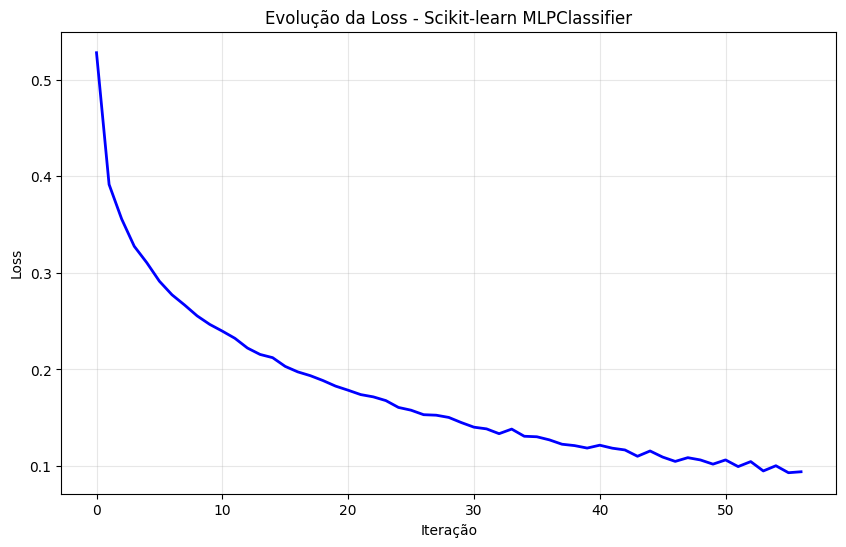


Arquitetura da rede treinada:
Camadas: [784, 128, 64, 10]
Número total de parâmetros: 109386


In [ ]:
# Visualização da curva de loss
plt.figure(figsize=(10, 6))
plt.plot(model_sklearn.loss_curve_, linewidth=2, color='blue')
plt.title('Evolução da Loss - Scikit-learn MLPClassifier')
plt.xlabel('Iteração')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

# Informações sobre a arquitetura treinada
print(f"\nArquitetura da rede treinada:")
print(f"Camadas: {[dataTrainScaled.shape[1]] + list(model_sklearn.hidden_layer_sizes) + [len(np.unique(targetTrain))]}")
print(f"Número total de parâmetros: {sum(w.size for w in model_sklearn.coefs_) + sum(b.size for b in model_sklearn.intercepts_)}")

In [ ]:
# Predições no conjunto de teste
sklearn_predictions = model_sklearn.predict(dataTestScaled)

# Cálculo do F1-score
sklearn_f1 = skl.metrics.f1_score(targetTest, sklearn_predictions, average='weighted')

print(f"F1-score scikit-learn: {sklearn_f1:.4f}")
print(f"Tempo de treinamento: {sklearn_train_time:.2f} segundos")

# Relatório de classificação
print("\nRelatório de Classificação - Scikit-learn:")
print(skl.metrics.classification_report(targetTest, sklearn_predictions))

F1-score scikit-learn: 0.8830
Tempo de treinamento: 714.27 segundos

Relatório de Classificação - Scikit-learn:
              precision    recall  f1-score   support

           0       0.80      0.85      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.80      0.81      0.81      1000
           3       0.88      0.90      0.89      1000
           4       0.81      0.82      0.81      1000
           5       0.96      0.97      0.96      1000
           6       0.73      0.65      0.68      1000
           7       0.94      0.94      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [16]:
# Configuração da validação cruzada
cv_folds = 5
skf = skl.model_selection.StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# Modelo para validação cruzada (configuração mais simples para velocidade)
model_cv = skl.neural_network.MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

print("Executando validação cruzada...")
start_time = time.time()

# Usando dados de treino + validação para CV
X_cv = np.vstack([dataTrainScaled, dataValScaled])
y_cv = np.hstack([targetTrain, targetVal])

cv_scores = skl.model_selection.cross_val_score(model_cv, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)

cv_time = time.time() - start_time

print(f"\nResultados da Validação Cruzada ({cv_folds} folds):")
print(f"F1-scores: {cv_scores}")
print(f"Média: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Tempo total: {cv_time:.2f} segundos")

Executando validação cruzada...


KeyboardInterrupt: 

In [ ]:
# Visualização dos resultados da validação cruzada
plt.figure(figsize=(10, 6))

plt.boxplot(cv_scores, labels=['CV Scores'])
plt.scatter([1] * len(cv_scores), cv_scores, alpha=0.7, s=50)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Média: {cv_scores.mean():.4f}')
plt.title('Distribuição dos F1-scores na Validação Cruzada')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comparison

In [ ]:
# Criação da tabela comparativa
import pandas as pd

results_df = pd.DataFrame({
    'Implementação': ['PyTorch', 'Scikit-learn', 'CV (Scikit-learn)'],
    'F1-Score': [pytorch_f1, sklearn_f1, cv_scores.mean()],
    'Desvio Padrão': ['-', '-', cv_scores.std()],
    'Tempo (s)': [pytorch_train_time, sklearn_train_time, cv_time],
    'Arquitetura': ['[64, 128, 64, 10]', '[64, 128, 64, 10]', '[64, 100, 10]']
})

print("COMPARAÇÃO DE RESULTADOS")
print("=" * 50)
print(results_df.to_string(index=False))

# Análise dos resultados
print("\nANÁLISE DOS RESULTADOS:")
print("=" * 30)

if pytorch_f1 > sklearn_f1:
    print(f"✓ PyTorch obteve melhor F1-score (+{(pytorch_f1-sklearn_f1)*100:.2f}%)")
else:
    print(f"✓ Scikit-learn obteve melhor F1-score (+{(sklearn_f1-pytorch_f1)*100:.2f}%)")

if pytorch_train_time < sklearn_train_time:
    print(f"✓ PyTorch foi mais rápido (-{((sklearn_train_time-pytorch_train_time)/sklearn_train_time)*100:.1f}%)")
else:
    print(f"✓ Scikit-learn foi mais rápido (-{((pytorch_train_time-sklearn_train_time)/pytorch_train_time)*100:.1f}%)")

print(f"\n• Validação cruzada mostrou F1-score médio de {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"• Intervalo de confiança (95%): [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

In [ ]:
# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Comparação F1-Score
implementations = ['PyTorch', 'Scikit-learn']
f1_scores = [pytorch_f1, sklearn_f1]
colors = ['#FF6B6B', '#4ECDC4']

bars1 = ax1.bar(implementations, f1_scores, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('Comparação F1-Score', fontsize=14, fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0.85, 1.0)
ax1.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, score in zip(bars1, f1_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Comparação Tempo de Treinamento
train_times = [pytorch_train_time, sklearn_train_time]

bars2 = ax2.bar(implementations, train_times, color=colors, alpha=0.8, edgecolor='black')
ax2.set_title('Comparação Tempo de Treinamento', fontsize=14, fontweight='bold')
ax2.set_ylabel('Tempo (segundos)')
ax2.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, time_val in zip(bars2, train_times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(train_times)*0.02,
             f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Matrizes de confusão
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PyTorch
cm_pytorch = skl.metrics.confusion_matrix(targetTest, pytorch_predictions)
sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title(f'Matriz de Confusão - PyTorch\nF1-Score: {pytorch_f1:.4f}')
ax1.set_xlabel('Predição')
ax1.set_ylabel('Real')

# Scikit-learn
cm_sklearn = skl.metrics.confusion_matrix(targetTest, sklearn_predictions)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title(f'Matriz de Confusão - Scikit-learn\nF1-Score: {sklearn_f1:.4f}')
ax2.set_xlabel('Predição')
ax2.set_ylabel('Real')

plt.tight_layout()
plt.show()

# PyTorch Activation Function and Optimazer

In [11]:
import copy

activation_names = ['relu', 'leaky_relu', 'elu', 'swish']
optimizer_configs = {
    'Adam':    lambda p: tr.optim.Adam(p,    lr=0.001, weight_decay=1e-4),
    'AdamW':   lambda p: tr.optim.AdamW(p,   lr=0.001, weight_decay=1e-3),
    'RMSprop': lambda p: tr.optim.RMSprop(p, lr=0.001, momentum=0.9),
}

pt_results = {}

for act_name in activation_names:
    for opt_name, opt_fn in optimizer_configs.items():
        key = f"{act_name}+{opt_name}"
        model = MLPPyTorch(784, [256, 128], 10, dropout_rate=0.2, activation=act_name).to(device)
        optimizer = opt_fn(model.parameters())
        for epoch in range(num_epochs):
            train_epoch(model, trainLoader, criterion, optimizer)
        _, val_acc = validate(model, valLoader, criterion)
        pt_results[key] = val_acc
        print(f"{key}: val_acc={val_acc:.4f}")

best = max(pt_results, key=pt_results.get)
print(f"\nMelhor combinação PyTorch: {best} ({pt_results[best]:.4f})")

relu+Adam: val_acc=0.8933
relu+AdamW: val_acc=0.8965
relu+RMSprop: val_acc=0.8176
leaky_relu+Adam: val_acc=0.8955
leaky_relu+AdamW: val_acc=0.9025
leaky_relu+RMSprop: val_acc=0.8548
elu+Adam: val_acc=0.8838
elu+AdamW: val_acc=0.8989
elu+RMSprop: val_acc=0.8457
swish+Adam: val_acc=0.8995
swish+AdamW: val_acc=0.8974
swish+RMSprop: val_acc=0.8414

Melhor combinação PyTorch: leaky_relu+AdamW (0.9025)


Melhor combinação PyTorch: leaky_relu+AdamW (0.9025)

# Sklearn Activation Function and Optimazer

In [17]:
sk_configs = {
    'relu+adam':    dict(activation='relu',    solver='adam'),
    'relu+sgd':     dict(activation='relu',    solver='sgd', momentum=0.9),
    'tanh+adam':    dict(activation='tanh',    solver='adam'),
    'logistic+adam':dict(activation='logistic',solver='adam'),
}

sk_results = {}

for name, cfg in sk_configs.items():
    clf = skl.neural_network.MLPClassifier(
      hidden_layer_sizes=(256, 128),  # Mesma arquitetura do PyTorch
      alpha=1e-4,                     # Regularização L2
      batch_size=32,                  # Tamanho do batch
      learning_rate_init=0.001,       # Taxa de aprendizado
      max_iter=500,                   # Máximo de iterações
      early_stopping=True,            # Parada antecipada
      validation_fraction=0.1,        # Fração para validação
      n_iter_no_change=20,            # Paciência para parada
      random_state=42,      # Reprodutibilidade
      verbose=False,                   # Não mostrar progresso
      **cfg
  )

    clf.fit(dataTrainScaled, targetTrain)
    val_acc = skl.metrics.accuracy_score(targetVal, clf.predict(dataValScaled))
    sk_results[name] = val_acc
    print(f"{name}: val_acc={val_acc:.4f}")

best_sk = max(sk_results, key=sk_results.get)
print(f"\nMelhor combinação Sklearn: {best_sk} ({sk_results[best_sk]:.4f})")

relu+adam: val_acc=0.8968


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


relu+sgd: val_acc=0.8980


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


tanh+adam: val_acc=0.0539


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


logistic+adam: val_acc=0.1000

Melhor combinação Sklearn: relu+sgd (0.8980)


# PyTorch Neural Network Size

In [15]:
import copy

activationConfig = 'leaky_relu'
optimizer_fn = lambda p: tr.optim.AdamW(p, lr=0.001, weight_decay=1e-3)

neuronConfigurations = neuronConfigurations = [
    [128],           # shallow small
    [512],           # shallow large
    [256, 128],      # baseline
    [512, 256],      # wider
    [256, 128, 64],  # deeper
    [512, 256, 128], # wide and deep
    [128, 128, 128], # uniform
    [64, 128, 256],  # inverted pyramid (expanding)
]

pt_results = {}

for neurons in neuronConfigurations:
    key = f"{activationConfig}+AdamW+{neurons}"
    model = MLPPyTorch(784, neurons, 10, dropout_rate=0.2, activation=activationConfig).to(device)
    optimizer = optimizer_fn(model.parameters())
    for epoch in range(num_epochs):
        train_epoch(model, trainLoader, criterion, optimizer)
    _, val_acc = validate(model, valLoader, criterion)
    pt_results[key] = val_acc
    print(f"{key}: val_acc={val_acc:.4f}")

best = max(pt_results, key=pt_results.get)
print(f"\nMelhor configuração: {best} ({pt_results[best]:.4f})")

leaky_relu+AdamW+[128]: val_acc=0.8911


KeyboardInterrupt: 

#Sklearn Neural Network Size

In [ ]:
neuronConfigurations = neuronConfigurations = [
    [128],           # shallow small
    [512],           # shallow large
    [256, 128],      # baseline
    [512, 256],      # wider
    [256, 128, 64],  # deeper
    [512, 256, 128], # wide and deep
    [128, 128, 128], # uniform
    [64, 128, 256],  # inverted pyramid (expanding)
]

sk_configs = {
    '[128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(128)),
    '[512]':     dict(activation='relu', solver='adam' , hidden_layer_sizes=(512)),
    '[256, 128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(256, 128)),
    '[512, 256]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(512, 256)),
    '[256, 128, 64]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(256, 128, 64)),
    '[512, 256, 128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(512, 256, 128)),
    '[128, 128, 128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(128, 128, 128)),
    '[64, 128, 256]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(64, 128, 256)),
}

sk_results = {}

for name, cfg in sk_configs.items():
    clf = skl.neural_network.MLPClassifier(
      alpha=1e-4,                     # Regularização L2
      batch_size=32,                  # Tamanho do batch
      learning_rate_init=0.001,       # Taxa de aprendizado
      max_iter=500,                   # Máximo de iterações
      early_stopping=True,            # Parada antecipada
      validation_fraction=0.1,        # Fração para validação
      n_iter_no_change=20,            # Paciência para parada
      random_state=42,      # Reprodutibilidade
      verbose=False,                   # Não mostrar progresso
      **cfg
  )

    clf.fit(dataTrainScaled, targetTrain)
    val_acc = skl.metrics.accuracy_score(targetVal, clf.predict(dataValScaled))
    sk_results[name] = val_acc
    print(f"{name}: val_acc={val_acc:.4f}")

best_sk = max(sk_results, key=sk_results.get)
print(f"\nMelhor combinação Sklearn: {best_sk} ({sk_results[best_sk]:.4f})")

[128]: val_acc=0.8956


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


[512]: val_acc=0.8917


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


[256, 128]: val_acc=0.0535


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


[512, 256]: val_acc=0.1020


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


[256, 128, 64]: val_acc=0.8725
